# Onset extraction: metronome clicks + tapping onsets/accents

*2026-07-10 Roberto Barumerli*

Extracts, per trial:
- metronome click times (from `*_metronome.wav`)
- tap onset times + accent amplitude (from the plain mic `*.wav`)

and saves tidy event tables + per-trial QC plots.

Run with the `bayesian_listener` conda environment (librosa installed there).

In [1]:
import re
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

RNG_SEED = 0

## 0. Config

The whole pipeline (Sections 1-10) runs once per subject. `SUBJECTS` is
discovered from every `subNN` folder under `save/` that has a log csv, so
adding a new subject's data is enough to have them picked up here without
editing this notebook.

In [2]:
DATA_ROOT = Path("/Users/robaru/repos/meterswitch/save")
OUT_ROOT = Path("/Users/robaru/repos/meterswitch/save/derived")
PHASES = ["famil", "prime", "test"]  # folders to scan for each subject

SUBJECTS = sorted(
    p.name for p in DATA_ROOT.iterdir()
    if p.is_dir() and (p / f"{p.name}_log.csv").exists()
)
print("Subjects found:", SUBJECTS)

Subjects found: ['sub01', 'sub02']


In [3]:
# --- everything below runs once per subject in SUBJECTS ---
SUBJECT = SUBJECTS[0]  # set for interactive/step-by-step use; overridden by the batch loop at the end

SUBJECT_DIR = DATA_ROOT / SUBJECT
LOG_CSV = SUBJECT_DIR / f"{SUBJECT}_log.csv"

OUT_DIR = OUT_ROOT / SUBJECT
QC_DIR = OUT_DIR / "qc_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
QC_DIR.mkdir(parents=True, exist_ok=True)

print("Subject dir:", SUBJECT_DIR)
print("Log csv:", LOG_CSV)

Subject dir: /Users/robaru/repos/meterswitch/save/sub01
Log csv: /Users/robaru/repos/meterswitch/save/sub01/sub01_log.csv


## 1. Build the trial manifest

Join `sub01_log.csv` with the actual wav files found on disk. File naming:
`trial{TrialNumber}_{meter}_{condition}.wav` and the metronome twin
`trial{TrialNumber}_{meter}_{condition}_metronome.wav`, except spontaneous
`test` trials which carry an extra `_spontaneous` / `_cued` suffix before
`_metronome` (e.g. `trial1_3_spontaneous.wav`).

In [4]:
df_log = pd.read_csv(LOG_CSV)
df_log.columns = [c.strip() for c in df_log.columns]
df_log

,condition,meter,BPM,SwitchTime,Subject,TrialNumber
0,spontaneous,3,120,0,sub01,1
1,cued,3,104,14,sub01,2
2,cued,2,108,16,sub01,3
3,spontaneous,2,116,0,sub01,4
4,spontaneous,3,108,0,sub01,5
5,spontaneous,2,112,0,sub01,6
6,cued,3,112,12,sub01,7
7,spontaneous,3,112,0,sub01,8
8,spontaneous,3,100,0,sub01,9
9,cued,2,112,16,sub01,10


In [5]:
def find_trial_files(phase_dir: Path, trial_number: int, meter: int):
    """Return (mic_path, metronome_path) for a given trial in phase_dir, or (None, None)."""
    candidates = sorted(phase_dir.glob(f"trial{trial_number}_{meter}_*.wav"))
    mic_path, metro_path = None, None
    for p in candidates:
        if p.stem.endswith("_metronome"):
            if metro_path is None:
                metro_path = p
        else:
            if mic_path is None:
                mic_path = p
    return mic_path, metro_path


manifest_rows = []
for phase in PHASES:
    phase_dir = SUBJECT_DIR / phase
    if not phase_dir.exists():
        continue
    for _, row in df_log.iterrows():
        mic_path, metro_path = find_trial_files(phase_dir, int(row["TrialNumber"]), int(row["meter"]))
        if mic_path is None and metro_path is None:
            continue  # this trial doesn't live in this phase folder
        manifest_rows.append({
            "subject": SUBJECT,
            "phase": phase,
            "trial": int(row["TrialNumber"]),
            "condition": row["condition"],
            "meter": int(row["meter"]),
            "bpm": float(row["BPM"]),
            "switch_time": int(row["SwitchTime"]),
            "mic_path": mic_path,
            "metro_path": metro_path,
        })

df_manifest = pd.DataFrame(manifest_rows)
missing = df_manifest[df_manifest["mic_path"].isna() | df_manifest["metro_path"].isna()]
if len(missing):
    print(f"WARNING: {len(missing)} trial(s) missing one of the two wav files:")
    print(missing[["phase", "trial", "condition"]])
df_manifest = df_manifest.dropna(subset=["mic_path", "metro_path"]).reset_index(drop=True)
print(f"Manifest: {len(df_manifest)} trials found across phases {sorted(df_manifest['phase'].unique())}")
df_manifest.head()

    phase  trial    condition
0   famil      2         cued
1   prime      1  spontaneous
2   prime      2         cued
3   prime      3         cued
4   prime      4  spontaneous
5   prime      5  spontaneous
6   prime      6  spontaneous
7   prime      7         cued
8   prime      8  spontaneous
9   prime      9  spontaneous
10  prime     10         cued
11  prime     11  spontaneous
12  prime     12  spontaneous
13  prime     13         cued
14  prime     14         cued
15  prime     15  spontaneous
16  prime     16         cued
17  prime     17  spontaneous
18  prime     18         cued
19  prime     19         cued
20  prime     20         cued
Manifest: 20 trials found across phases ['test']


,subject,phase,trial,condition,meter,bpm,switch_time,mic_path,metro_path
0,sub01,test,1,spontaneous,3,120.0,0,/Users/robaru/repos/meterswitch/save/sub01/tes...,/Users/robaru/repos/meterswitch/save/sub01/tes...
1,sub01,test,2,cued,3,104.0,14,/Users/robaru/repos/meterswitch/save/sub01/tes...,/Users/robaru/repos/meterswitch/save/sub01/tes...
2,sub01,test,3,cued,2,108.0,16,/Users/robaru/repos/meterswitch/save/sub01/tes...,/Users/robaru/repos/meterswitch/save/sub01/tes...
3,sub01,test,4,spontaneous,2,116.0,0,/Users/robaru/repos/meterswitch/save/sub01/tes...,/Users/robaru/repos/meterswitch/save/sub01/tes...
4,sub01,test,5,spontaneous,3,108.0,0,/Users/robaru/repos/meterswitch/save/sub01/tes...,/Users/robaru/repos/meterswitch/save/sub01/tes...


## 2. Audio loading helpers

In [6]:
def load_mic(path: Path):
    y, sr = librosa.load(str(path), sr=None, mono=True)
    return y, sr


def load_metronome(path: Path):
    y, sr = librosa.load(str(path), sr=None, mono=False)
    if y.ndim == 2:
        # verify channels are (near-)identical; fall back to channel 0 regardless
        if y.shape[0] >= 2:
            max_diff = np.max(np.abs(y[0] - y[1]))
            if max_diff > 1e-3:
                print(f"NOTE: metronome channels differ (max abs diff {max_diff:.4f}) for {path.name}")
        y = y[0]
    return y, sr


def check_alignment(mic_y, metro_y, sr, tol_ms=50):
    dur_mic = len(mic_y) / sr
    dur_metro = len(metro_y) / sr
    diff_ms = abs(dur_mic - dur_metro) * 1000
    if diff_ms > tol_ms:
        print(f"WARNING: mic/metronome duration mismatch: {diff_ms:.1f} ms "
              f"(mic {dur_mic:.3f}s vs metronome {dur_metro:.3f}s)")
    return diff_ms

## 3. Metronome click detection

Clicks are strong, short, and isochronous at the trial's BPM. Peak-pick the
rectified signal with a minimum distance derived from BPM, then verify IOI
regularity as a QC signal.

In [7]:
def detect_clicks(y, sr, bpm, height=0.5, min_ioi_frac=0.5):
    min_distance = int(sr * (60.0 / bpm) * min_ioi_frac)
    peaks, props = find_peaks(np.abs(y), height=height, distance=max(min_distance, 1))
    times = peaks / sr
    iois = np.diff(times)
    expected_ioi = 60.0 / bpm
    ioi_std = float(np.std(iois)) if len(iois) else np.nan
    ioi_mean = float(np.mean(iois)) if len(iois) else np.nan
    flagged = (
        len(times) == 0
        or (not np.isnan(ioi_std) and ioi_std > 0.15 * expected_ioi)
        or (not np.isnan(ioi_mean) and abs(ioi_mean - expected_ioi) > 0.25 * expected_ioi)
    )
    return times, {"ioi_mean": ioi_mean, "ioi_std": ioi_std, "expected_ioi": expected_ioi, "n_clicks": len(times), "flagged": flagged}

## 4. Tap onset detection (mic channel)

The mic signal turned out to be dominated by low-frequency rumble/hum
(spectral peak ~23 Hz) sitting under the much broader-band tap transients
(spectral peak ~94 Hz) — librosa's spectral-flux `onset_detect` was
tripping on that rumble and massively over-counting (~190 "taps" in a
trial with only ~60 real ones). Fix: high-pass filter first to remove the
rumble, then peak-pick a lightly smoothed rectified envelope.

Absolute recording level varies a lot trial-to-trial (some trials are far
quieter/noisier than others), so a single fixed amplitude threshold either
missed almost everything on quiet trials or over-fired on loud ones. The
threshold is instead set per trial from the envelope's own noise floor:
`median + k * MAD` (a robust, outlier-resistant estimate of "typical
background" for that specific recording), so a peak has to stand out from
*that trial's* noise, not from a global constant.

Some trials (see QC plots) are simply low-SNR throughout with no cleanly
isolated transients — detections there are lower-confidence and worth a
visual spot-check rather than blind trust.

In [8]:
def detect_taps(y, sr, highpass_hz=80, smooth_ms=3, min_gap_s=0.15, mad_k=8):
    sos = signal.butter(4, highpass_hz, btype="highpass", fs=sr, output="sos")
    y_hp = signal.sosfiltfilt(sos, y)

    env = np.abs(y_hp)
    win = max(int(sr * smooth_ms / 1000), 1)
    env_smooth = np.convolve(env, np.ones(win) / win, mode="same")

    med = np.median(env_smooth)
    mad = np.median(np.abs(env_smooth - med))
    threshold = med + mad_k * mad

    peaks, props = find_peaks(env_smooth, height=threshold, distance=int(sr * min_gap_s))
    times = peaks / sr

    # how far the detected peaks stand above this trial's own noise floor --
    # a trial can have a plausible *tap count* purely because the adaptive
    # threshold always finds *some* peaks, even in pure noise, so the count
    # alone can't tell a clean detection from a marginal one. This ratio can.
    snr_ratio = float(props["peak_heights"].mean() / med) if len(peaks) and med > 0 else np.nan

    return times, env_smooth, snr_ratio


def check_metronome_bleed(tap_times, click_times, tol_s=0.02):
    """Flag suspiciously high overlap between detected taps and click times
    (possible metronome bleed into the mic channel)."""
    if len(tap_times) == 0 or len(click_times) == 0:
        return 0.0
    hits = 0
    for t in tap_times:
        if np.min(np.abs(click_times - t)) < tol_s:
            hits += 1
    return hits / len(tap_times)


def is_low_confidence_trial(n_taps, expected_n_clicks, snr_ratio,
                             tap_count_ratio_bounds=(0.5, 2.0), snr_min=10.0):
    """Flag a trial as low-confidence if either:
    - the detected tap count is implausible relative to expected beats (far
      too few/many), or
    - the detected peaks don't stand out much above that trial's own noise
      floor (snr_ratio, from detect_taps) -- the adaptive MAD threshold in
      detect_taps will always find *some* peaks even in near-pure noise, so
      tap count alone can't distinguish a clean recording from a marginal
      one; snr_ratio can.
    This is a coarse, cheap sanity check meant to steer a human to the QC
    plot, not a hard exclusion criterion."""
    if expected_n_clicks == 0:
        return True
    ratio = n_taps / expected_n_clicks
    lo, hi = tap_count_ratio_bounds
    count_flag = ratio < lo or ratio > hi
    snr_flag = np.isnan(snr_ratio) or snr_ratio < snr_min
    return bool(count_flag or snr_flag)

## 5. Accent / amplitude extraction per tap

For each tap onset, compute peak amplitude and RMS (in dB) in a short
window following the onset.

In [9]:
def tap_accents(y, sr, tap_times, window_s=0.03):
    win = int(sr * window_s)
    peak_amp, rms_db = [], []
    for t in tap_times:
        start = int(t * sr)
        end = min(start + win, len(y))
        seg = y[start:end]
        if len(seg) == 0:
            peak_amp.append(np.nan)
            rms_db.append(np.nan)
            continue
        p = float(np.max(np.abs(seg)))
        rms = float(np.sqrt(np.mean(seg ** 2)))
        peak_amp.append(p)
        rms_db.append(20 * np.log10(max(rms, 1e-8)))
    return np.array(peak_amp), np.array(rms_db)

## 6. Per-trial QC plot

Top: mic waveform with detected tap onsets (stem height = accent). Bottom:
metronome waveform with detected clicks, plus tap times overlaid (dashed)
to visually check tap/beat alignment.

In [10]:
def plot_trial_qc(trial_row, mic_y, sr_mic, metro_y, sr_metro,
                   tap_times, rms_db, click_times, out_path):
    t_mic = np.arange(len(mic_y)) / sr_mic
    t_metro = np.arange(len(metro_y)) / sr_metro

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True, layout="constrained")

    ax1.plot(t_mic, mic_y, color="0.6", lw=0.5)
    if len(tap_times):
        norm = (rms_db - np.nanmin(rms_db)) / (np.ptp(rms_db) + 1e-9)
        ax1.vlines(tap_times, 0, norm * np.nanmax(np.abs(mic_y)), color="C3", lw=1.2)
        ax1.scatter(tap_times, np.full_like(tap_times, np.nanmax(np.abs(mic_y)) * 1.05),
                    color="C3", marker="v", s=15, label="tap onset")
    ax1.set_ylabel("mic amplitude")
    ax1.legend(fontsize=8, loc="upper right")

    ax2.plot(t_metro, metro_y, color="0.6", lw=0.5)
    if len(click_times):
        ax2.vlines(click_times, -1, 1, color="C0", lw=0.8, label="click")
    if len(tap_times):
        ax2.vlines(tap_times, -1, 1, color="C3", lw=0.8, ls="--", alpha=0.7, label="tap (overlay)")
    ax2.set_ylabel("metronome amplitude")
    ax2.set_xlabel("time (s)")
    ax2.legend(fontsize=8, loc="upper right")

    fig.suptitle(
        f"{trial_row['subject']} trial {trial_row['trial']} ({trial_row['phase']}) — "
        f"{trial_row['condition']}, meter {trial_row['meter']}, {trial_row['bpm']:.0f} BPM, "
        f"switch_time={trial_row['switch_time']}",
        fontsize=10,
    )
    fig.savefig(out_path, dpi=110)
    plt.close(fig)

## 7. Batch driver: run the pipeline over every trial in the manifest

In [11]:
metronome_events = []
tap_events = []
trial_qc_summary = []

for _, row in df_manifest.iterrows():
    mic_y, sr_mic = load_mic(row["mic_path"])
    metro_y, sr_metro = load_metronome(row["metro_path"])
    assert sr_mic == sr_metro, f"sample rate mismatch for trial {row['trial']}"
    sr = sr_mic

    dur_diff_ms = check_alignment(mic_y, metro_y, sr)

    click_times, click_qc = detect_clicks(metro_y, sr, row["bpm"])
    tap_times, onset_env, snr_ratio = detect_taps(mic_y, sr)
    peak_amp, rms_db = tap_accents(mic_y, sr, tap_times)
    bleed_frac = check_metronome_bleed(tap_times, click_times)

    for i, ct in enumerate(click_times):
        metronome_events.append({
            "subject": row["subject"], "phase": row["phase"], "trial": row["trial"],
            "condition": row["condition"], "meter": row["meter"], "bpm": row["bpm"],
            "switch_time": row["switch_time"], "click_idx": i, "click_time_s": ct,
        })

    for i, (tt, pa, rd) in enumerate(zip(tap_times, peak_amp, rms_db)):
        tap_events.append({
            "subject": row["subject"], "phase": row["phase"], "trial": row["trial"],
            "condition": row["condition"], "meter": row["meter"], "bpm": row["bpm"],
            "switch_time": row["switch_time"], "tap_idx": i, "tap_time_s": tt,
            "peak_amp": pa, "rms_db": rd,
        })

    expected_n_clicks = int(np.floor((len(metro_y) / sr) / (60.0 / row["bpm"])))
    low_confidence = is_low_confidence_trial(len(tap_times), expected_n_clicks, snr_ratio)
    trial_qc_summary.append({
        "subject": row["subject"], "phase": row["phase"], "trial": row["trial"],
        "condition": row["condition"], "n_clicks": click_qc["n_clicks"],
        "expected_n_clicks": expected_n_clicks,
        "click_ioi_std_ms": click_qc["ioi_std"] * 1000 if not np.isnan(click_qc["ioi_std"]) else np.nan,
        "click_flagged": click_qc["flagged"],
        "n_taps": len(tap_times),
        "snr_ratio": snr_ratio,
        "bleed_frac": bleed_frac,
        "bleed_flagged": bleed_frac > 0.3,
        "low_confidence_trial": low_confidence,
        "duration_diff_ms": dur_diff_ms,
    })

    qc_path = QC_DIR / f"{row['subject']}_trial{row['trial']}_{row['phase']}.png"
    plot_trial_qc(row, mic_y, sr, metro_y, sr, tap_times, rms_db, click_times, qc_path)

df_metronome_events = pd.DataFrame(metronome_events)
df_tap_events = pd.DataFrame(tap_events)
df_qc = pd.DataFrame(trial_qc_summary)

print(f"{len(df_manifest)} trials processed")
print(f"Flagged trials (click irregularity, bleed, or low-confidence tap count):")
df_qc[df_qc["click_flagged"] | df_qc["bleed_flagged"] | df_qc["low_confidence_trial"]]

20 trials processed
Flagged trials (click irregularity, bleed, or low-confidence tap count):


,subject,phase,trial,condition,n_clicks,expected_n_clicks,click_ioi_std_ms,click_flagged,n_taps,snr_ratio,bleed_frac,bleed_flagged,low_confidence_trial,duration_diff_ms
4,sub01,test,5,spontaneous,54,54,1.129330e-12,False,70,7.561511,0.071429,False,True,0.354167
5,sub01,test,6,spontaneous,56,56,1.217017e-12,False,63,5.394053,0.111111,False,True,0.354167
6,sub01,test,7,cued,56,56,1.217017e-12,False,65,6.173234,0.230769,False,True,28.312500
7,sub01,test,8,spontaneous,56,56,1.217017e-12,False,67,8.074010,0.149254,False,True,0.354167
8,sub01,test,9,spontaneous,50,50,1.245617e-12,False,61,8.191906,0.065574,False,True,0.354167
9,sub01,test,10,cued,56,56,1.217017e-12,False,50,5.538535,0.060000,False,True,28.312500
10,sub01,test,11,spontaneous,52,52,1.158585e-12,False,49,4.854714,0.102041,False,True,0.354167
11,sub01,test,12,spontaneous,60,60,2.653378e-13,False,67,5.560552,0.089552,False,True,0.354167
12,sub01,test,13,cued,50,50,1.245617e-12,False,54,6.518899,0.092593,False,True,28.312500
13,sub01,test,14,cued,52,52,1.158585e-12,False,61,5.914323,0.032787,False,True,28.312500


## 8. Save event tables + QC summary

In [12]:
df_metronome_events.to_csv(OUT_DIR / f"{SUBJECT}_metronome_events.csv", index=False)
df_tap_events.to_csv(OUT_DIR / f"{SUBJECT}_tap_events.csv", index=False)
df_qc.to_csv(OUT_DIR / f"{SUBJECT}_qc_summary.csv", index=False)

print("Saved:")
print(" -", OUT_DIR / f"{SUBJECT}_metronome_events.csv")
print(" -", OUT_DIR / f"{SUBJECT}_tap_events.csv")
print(" -", OUT_DIR / f"{SUBJECT}_qc_summary.csv")
print(" - per-trial QC plots in", QC_DIR)

Saved:
 - /Users/robaru/repos/meterswitch/derived/sub01/sub01_metronome_events.csv
 - /Users/robaru/repos/meterswitch/derived/sub01/sub01_tap_events.csv
 - /Users/robaru/repos/meterswitch/derived/sub01/sub01_qc_summary.csv
 - per-trial QC plots in /Users/robaru/repos/meterswitch/derived/sub01/qc_plots


## 9. Summary plots across all trials

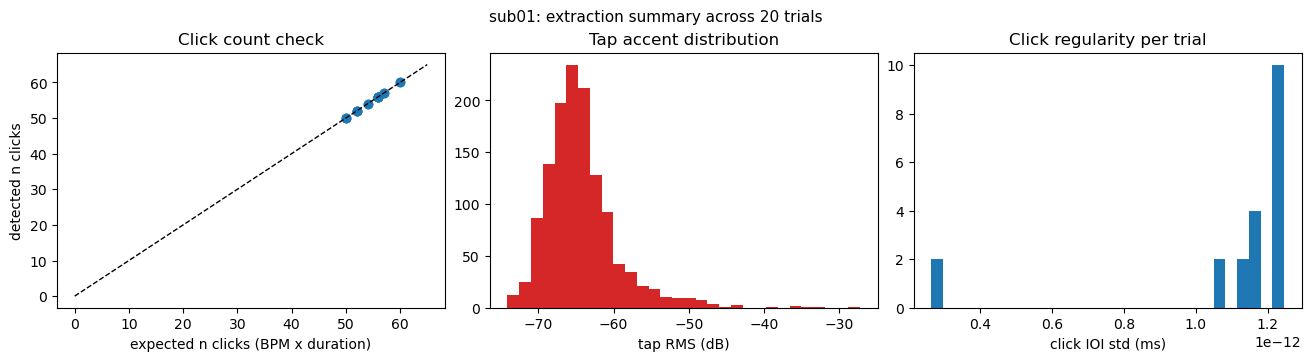

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), layout="constrained")

axes[0].scatter(df_qc["expected_n_clicks"], df_qc["n_clicks"], color="C0")
lims = [0, max(df_qc["expected_n_clicks"].max(), df_qc["n_clicks"].max()) + 5]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("expected n clicks (BPM x duration)")
axes[0].set_ylabel("detected n clicks")
axes[0].set_title("Click count check")

axes[1].hist(df_tap_events["rms_db"].dropna(), bins=30, color="C3")
axes[1].set_xlabel("tap RMS (dB)")
axes[1].set_title("Tap accent distribution")

axes[2].hist(df_qc["click_ioi_std_ms"].dropna(), bins=30, color="C0")
axes[2].set_xlabel("click IOI std (ms)")
axes[2].set_title("Click regularity per trial")

fig.suptitle(f"{SUBJECT}: extraction summary across {len(df_manifest)} trials", fontsize=11)
plt.show()

## 10. Align taps to clicks: per-click asynchrony, amplitude, and accent label

For each metronome click, find the closest tap within a tolerance window
(a fraction of the beat period) and record the signed asynchrony
`tap_time - click_time`. Once a tap is matched to a click it is "consumed"
and cannot be matched to a later click — this stops one loud/ambiguous tap
from being double-counted across two adjacent beats, and clicks with no
available tap in range are left as missed beats (`asynchrony_ms = NaN`),
rather than snapping to a distant unrelated tap.

The matched tap's amplitude (`peak_amp`, `rms_db`, from Section 5) is
carried along so we know how hard that beat was tapped. From that, each
matched beat gets an `accented` label: True if its `rms_db` is above the
*median rms_db for that trial* — accent is judged relative to how the
participant tapped within that specific trial, not against a fixed
loudness cutoff, since absolute recording level varies a lot across trials
(see Section 4). Missed beats get `accented = NA` (no tap, nothing to judge).

`low_confidence_trial` (from the QC summary, Section 7) is also carried
into this table so a trial with an implausible tap count can be filtered
or down-weighted directly from this one file, without a join.

This is computed post-hoc from the already-saved event tables, so it can be
re-run/re-tuned (tolerance fraction, accent rule) without redoing onset
detection.

In [14]:
def match_clicks_to_taps(click_times, tap_times, tap_rms_db, bpm, tol_frac=0.4):
    """For each click (in time order), claim the closest not-yet-used tap
    within tol_frac * beat_period. Returns one row per click, including the
    matched tap's rms_db and a within-trial relative accent label."""
    beat_period = 60.0 / bpm
    tol = tol_frac * beat_period

    tap_times = np.asarray(tap_times)
    tap_rms_db = np.asarray(tap_rms_db)
    used = np.zeros(len(tap_times), dtype=bool)

    rows = []
    for click_idx, ct in enumerate(click_times):
        available = ~used
        if not np.any(available):
            rows.append((click_idx, ct, np.nan, np.nan, np.nan, np.nan))
            continue
        avail_idx = np.where(available)[0]
        dists = np.abs(tap_times[avail_idx] - ct)
        best = avail_idx[np.argmin(dists)]
        best_dist = dists.min()
        if best_dist <= tol:
            used[best] = True
            asynchrony_s = tap_times[best] - ct
            rows.append((click_idx, ct, tap_times[best], int(best), asynchrony_s, tap_rms_db[best]))
        else:
            rows.append((click_idx, ct, np.nan, np.nan, np.nan, np.nan))

    out = pd.DataFrame(rows, columns=[
        "click_idx", "click_time_s", "matched_tap_time_s", "matched_tap_idx",
        "asynchrony_s", "rms_db",
    ])
    out["asynchrony_ms"] = out["asynchrony_s"] * 1000
    out["missed_beat"] = out["matched_tap_time_s"].isna()

    median_rms_db = out["rms_db"].median()  # median over matched taps in this trial
    out["accented"] = np.where(out["missed_beat"], np.nan, out["rms_db"] > median_rms_db)
    return out


TOL_FRAC = 0.4  # fraction of beat period allowed as matching tolerance

alignment_rows = []
for _, row in df_manifest.iterrows():
    ct = df_metronome_events.query(
        "subject == @row.subject and phase == @row.phase and trial == @row.trial"
    )["click_time_s"].values
    tap_sub = df_tap_events.query(
        "subject == @row.subject and phase == @row.phase and trial == @row.trial"
    )
    tt = tap_sub["tap_time_s"].values
    tap_rms = tap_sub["rms_db"].values

    m = match_clicks_to_taps(ct, tt, tap_rms, row["bpm"], tol_frac=TOL_FRAC)
    m.insert(0, "trial", row["trial"])
    m.insert(0, "phase", row["phase"])
    m.insert(0, "subject", row["subject"])
    m["condition"] = row["condition"]
    m["meter"] = row["meter"]
    m["bpm"] = row["bpm"]
    m["switch_time"] = row["switch_time"]
    low_conf = df_qc.query(
        "subject == @row.subject and phase == @row.phase and trial == @row.trial"
    )["low_confidence_trial"].iloc[0]
    m["low_confidence_trial"] = low_conf
    alignment_rows.append(m)

df_alignment = pd.concat(alignment_rows, ignore_index=True)
df_alignment.to_csv(OUT_DIR / f"{SUBJECT}_click_tap_alignment.csv", index=False)

n_missed = df_alignment["missed_beat"].sum()
n_low_conf_trials = df_qc["low_confidence_trial"].sum()
print(f"{len(df_alignment)} clicks total, {n_missed} missed beats "
      f"({100 * n_missed / len(df_alignment):.1f}%)")
print(f"{n_low_conf_trials} / {len(df_manifest)} trials flagged low_confidence_trial")
print("Saved:", OUT_DIR / f"{SUBJECT}_click_tap_alignment.csv")
df_alignment.head(10)

1092 clicks total, 152 missed beats (13.9%)
15 / 20 trials flagged low_confidence_trial
Saved: /Users/robaru/repos/meterswitch/derived/sub01/sub01_click_tap_alignment.csv


,subject,phase,trial,click_idx,click_time_s,matched_tap_time_s,matched_tap_idx,asynchrony_s,rms_db,asynchrony_ms,missed_beat,accented,condition,meter,bpm,switch_time,low_confidence_trial
0,sub01,test,1,0,0.024438,NaN,NaN,NaN,NaN,NaN,True,NaN,spontaneous,3,120.0,0,False
1,sub01,test,1,1,0.524438,0.493521,0.0,-0.030917,-51.116308,-30.916667,False,1.0,spontaneous,3,120.0,0,False
2,sub01,test,1,2,1.024437,1.031333,1.0,0.006896,-59.799739,6.895833,False,0.0,spontaneous,3,120.0,0,False
3,sub01,test,1,3,1.524437,1.369208,2.0,-0.155229,-60.962212,-155.229167,False,0.0,spontaneous,3,120.0,0,False
4,sub01,test,1,4,2.024437,1.912854,3.0,-0.111583,-49.567057,-111.583333,False,1.0,spontaneous,3,120.0,0,False
5,sub01,test,1,5,2.524437,2.425500,4.0,-0.098937,-55.363678,-98.937500,False,0.0,spontaneous,3,120.0,0,False
6,sub01,test,1,6,3.024437,2.872021,5.0,-0.152417,-53.201601,-152.416667,False,1.0,spontaneous,3,120.0,0,False
7,sub01,test,1,7,3.524437,3.372500,6.0,-0.151937,-52.209202,-151.937500,False,1.0,spontaneous,3,120.0,0,False
8,sub01,test,1,8,4.024438,3.920583,7.0,-0.103854,-56.346986,-103.854167,False,0.0,spontaneous,3,120.0,0,False
9,sub01,test,1,9,4.524438,NaN,NaN,NaN,NaN,NaN,True,NaN,spontaneous,3,120.0,0,False


### Missed-beat rate per trial and asynchrony distribution

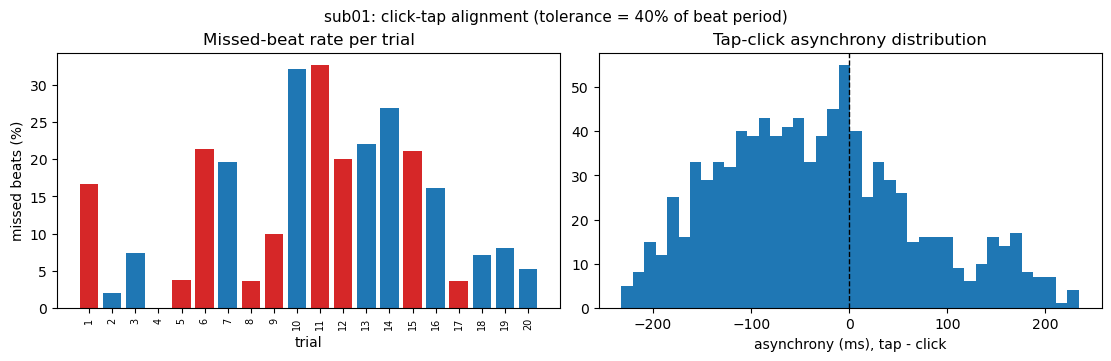

In [15]:
missed_per_trial = df_alignment.groupby(["trial", "condition"])["missed_beat"].mean().reset_index()
missed_per_trial = missed_per_trial.rename(columns={"missed_beat": "missed_beat_frac"})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), layout="constrained")

axes[0].bar(missed_per_trial["trial"].astype(str), missed_per_trial["missed_beat_frac"] * 100,
            color=["C0" if c == "cued" else "C3" for c in missed_per_trial["condition"]])
axes[0].set_xlabel("trial")
axes[0].set_ylabel("missed beats (%)")
axes[0].set_title("Missed-beat rate per trial")
axes[0].tick_params(axis="x", labelrotation=90, labelsize=7)

axes[1].hist(df_alignment["asynchrony_ms"].dropna(), bins=40, color="C0")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("asynchrony (ms), tap - click")
axes[1].set_title("Tap-click asynchrony distribution")

fig.suptitle(f"{SUBJECT}: click-tap alignment (tolerance = {TOL_FRAC:.0%} of beat period)", fontsize=11)
plt.show()

### Per-trial alignment QC plot

Extends the Section 6 plot: matched clicks are marked, missed beats are
highlighted, to visually confirm the matching makes sense against the raw
waveforms.

In [16]:
def plot_trial_alignment(trial_row, mic_y, sr, click_times, tap_times, alignment_trial, out_path):
    t_mic = np.arange(len(mic_y)) / sr
    fig, ax = plt.subplots(figsize=(12, 3), layout="constrained")
    ax.plot(t_mic, mic_y, color="0.7", lw=0.5)

    matched = alignment_trial.dropna(subset=["matched_tap_time_s"])
    missed = alignment_trial[alignment_trial["missed_beat"]]

    ymax = np.max(np.abs(mic_y))
    ax.vlines(click_times, -ymax * 1.2, ymax * 1.2, color="C0", lw=0.7, alpha=0.5, label="click")
    ax.scatter(matched["matched_tap_time_s"], np.full(len(matched), ymax * 1.1),
               color="C2", marker="v", s=25, zorder=5, label="matched tap")
    ax.vlines(missed["click_time_s"], -ymax * 1.2, ymax * 1.2, color="red", lw=1.5, ls=":", label="missed beat")

    ax.set_ylim(-ymax * 1.3, ymax * 1.3)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("mic amplitude")
    ax.legend(fontsize=8, loc="upper right", ncol=3)
    fig.suptitle(
        f"{trial_row['subject']} trial {trial_row['trial']} — click/tap alignment "
        f"({alignment_trial['missed_beat'].sum()} missed beats)",
        fontsize=10,
    )
    fig.savefig(out_path, dpi=110)
    plt.close(fig)


ALIGN_QC_DIR = OUT_DIR / "alignment_qc_plots"
ALIGN_QC_DIR.mkdir(exist_ok=True)

for _, row in df_manifest.iterrows():
    mic_y, sr = load_mic(row["mic_path"])
    ct = df_metronome_events.query(
        "subject == @row.subject and phase == @row.phase and trial == @row.trial"
    )["click_time_s"].values
    tt = df_tap_events.query(
        "subject == @row.subject and phase == @row.phase and trial == @row.trial"
    )["tap_time_s"].values
    align_trial = df_alignment.query(
        "subject == @row.subject and phase == @row.phase and trial == @row.trial"
    )
    out_path = ALIGN_QC_DIR / f"{row['subject']}_trial{row['trial']}_{row['phase']}_alignment.png"
    plot_trial_alignment(row, mic_y, sr, ct, tt, align_trial, out_path)

print("Saved per-trial alignment QC plots to", ALIGN_QC_DIR)

Saved per-trial alignment QC plots to /Users/robaru/repos/meterswitch/derived/sub01/alignment_qc_plots


## 11. Batch over every subject

Sections 1-10 above ran end-to-end for `SUBJECT = SUBJECTS[0]` as a
walkthrough. `run_pipeline_for_subject` repeats that exact same pipeline
(manifest -> click/tap detection -> QC plots -> click-tap alignment with
amplitude + accent label) for a given subject, so it can be re-run for
every subject found under `save/` without re-reading this whole notebook
top to bottom per subject.

In [17]:
def run_pipeline_for_subject(subject):
    subject_dir = DATA_ROOT / subject
    log_csv = subject_dir / f"{subject}_log.csv"
    out_dir = OUT_ROOT / subject
    qc_dir = out_dir / "qc_plots"
    align_qc_dir = out_dir / "alignment_qc_plots"
    out_dir.mkdir(parents=True, exist_ok=True)
    qc_dir.mkdir(parents=True, exist_ok=True)
    align_qc_dir.mkdir(parents=True, exist_ok=True)

    df_log = pd.read_csv(log_csv)
    df_log.columns = [c.strip() for c in df_log.columns]

    manifest_rows = []
    for phase in PHASES:
        phase_dir = subject_dir / phase
        if not phase_dir.exists():
            continue
        for _, row in df_log.iterrows():
            mic_path, metro_path = find_trial_files(phase_dir, int(row["TrialNumber"]), int(row["meter"]))
            if mic_path is None and metro_path is None:
                continue
            manifest_rows.append({
                "subject": subject, "phase": phase, "trial": int(row["TrialNumber"]),
                "condition": row["condition"], "meter": int(row["meter"]),
                "bpm": float(row["BPM"]), "switch_time": int(row["SwitchTime"]),
                "mic_path": mic_path, "metro_path": metro_path,
            })
    manifest = pd.DataFrame(manifest_rows)
    missing = manifest[manifest["mic_path"].isna() | manifest["metro_path"].isna()]
    if len(missing):
        print(f"[{subject}] WARNING: {len(missing)} trial(s) missing a wav file")
    manifest = manifest.dropna(subset=["mic_path", "metro_path"]).reset_index(drop=True)
    print(f"[{subject}] manifest: {len(manifest)} trials across phases {sorted(manifest['phase'].unique())}")

    metronome_events, tap_events, qc_summary = [], [], []
    for _, row in manifest.iterrows():
        mic_y, sr_mic = load_mic(row["mic_path"])
        metro_y, sr_metro = load_metronome(row["metro_path"])
        assert sr_mic == sr_metro, f"sample rate mismatch for trial {row['trial']}"
        sr = sr_mic

        dur_diff_ms = check_alignment(mic_y, metro_y, sr)
        click_times, click_qc = detect_clicks(metro_y, sr, row["bpm"])
        tap_times, _, snr_ratio = detect_taps(mic_y, sr)
        peak_amp, rms_db = tap_accents(mic_y, sr, tap_times)
        bleed_frac = check_metronome_bleed(tap_times, click_times)

        for i, ct in enumerate(click_times):
            metronome_events.append({
                "subject": subject, "phase": row["phase"], "trial": row["trial"],
                "condition": row["condition"], "meter": row["meter"], "bpm": row["bpm"],
                "switch_time": row["switch_time"], "click_idx": i, "click_time_s": ct,
            })
        for i, (tt, pa, rd) in enumerate(zip(tap_times, peak_amp, rms_db)):
            tap_events.append({
                "subject": subject, "phase": row["phase"], "trial": row["trial"],
                "condition": row["condition"], "meter": row["meter"], "bpm": row["bpm"],
                "switch_time": row["switch_time"], "tap_idx": i, "tap_time_s": tt,
                "peak_amp": pa, "rms_db": rd,
            })

        expected_n_clicks = int(np.floor((len(metro_y) / sr) / (60.0 / row["bpm"])))
        low_confidence = is_low_confidence_trial(len(tap_times), expected_n_clicks, snr_ratio)
        qc_summary.append({
            "subject": subject, "phase": row["phase"], "trial": row["trial"],
            "condition": row["condition"], "n_clicks": click_qc["n_clicks"],
            "expected_n_clicks": expected_n_clicks,
            "click_ioi_std_ms": click_qc["ioi_std"] * 1000 if not np.isnan(click_qc["ioi_std"]) else np.nan,
            "click_flagged": click_qc["flagged"], "n_taps": len(tap_times),
            "snr_ratio": snr_ratio,
            "bleed_frac": bleed_frac, "bleed_flagged": bleed_frac > 0.3,
            "low_confidence_trial": low_confidence, "duration_diff_ms": dur_diff_ms,
        })

        qc_path = qc_dir / f"{subject}_trial{row['trial']}_{row['phase']}.png"
        plot_trial_qc(row, mic_y, sr, metro_y, sr, tap_times, rms_db, click_times, qc_path)

    df_metro_ev = pd.DataFrame(metronome_events)
    df_tap_ev = pd.DataFrame(tap_events)
    df_qc_sub = pd.DataFrame(qc_summary)

    df_metro_ev.to_csv(out_dir / f"{subject}_metronome_events.csv", index=False)
    df_tap_ev.to_csv(out_dir / f"{subject}_tap_events.csv", index=False)
    df_qc_sub.to_csv(out_dir / f"{subject}_qc_summary.csv", index=False)

    alignment_rows = []
    for _, row in manifest.iterrows():
        ct = df_metro_ev.query(
            "subject == @row.subject and phase == @row.phase and trial == @row.trial"
        )["click_time_s"].values
        tap_sub = df_tap_ev.query(
            "subject == @row.subject and phase == @row.phase and trial == @row.trial"
        )
        tt = tap_sub["tap_time_s"].values
        tap_rms = tap_sub["rms_db"].values

        m = match_clicks_to_taps(ct, tt, tap_rms, row["bpm"], tol_frac=TOL_FRAC)
        m.insert(0, "trial", row["trial"])
        m.insert(0, "phase", row["phase"])
        m.insert(0, "subject", subject)
        m["condition"] = row["condition"]
        m["meter"] = row["meter"]
        m["bpm"] = row["bpm"]
        m["switch_time"] = row["switch_time"]
        low_conf = df_qc_sub.query(
            "subject == @row.subject and phase == @row.phase and trial == @row.trial"
        )["low_confidence_trial"].iloc[0]
        m["low_confidence_trial"] = low_conf
        alignment_rows.append(m)

    df_align_sub = pd.concat(alignment_rows, ignore_index=True)
    df_align_sub.to_csv(out_dir / f"{subject}_click_tap_alignment.csv", index=False)

    for _, row in manifest.iterrows():
        mic_y, sr = load_mic(row["mic_path"])
        ct = df_metro_ev.query(
            "subject == @row.subject and phase == @row.phase and trial == @row.trial"
        )["click_time_s"].values
        tt = df_tap_ev.query(
            "subject == @row.subject and phase == @row.phase and trial == @row.trial"
        )["tap_time_s"].values
        align_trial = df_align_sub.query(
            "subject == @row.subject and phase == @row.phase and trial == @row.trial"
        )
        out_path = align_qc_dir / f"{subject}_trial{row['trial']}_{row['phase']}_alignment.png"
        plot_trial_alignment(row, mic_y, sr, ct, tt, align_trial, out_path)

    n_missed = df_align_sub["missed_beat"].sum()
    n_low_conf = df_qc_sub["low_confidence_trial"].sum()
    print(f"[{subject}] {len(df_align_sub)} clicks, {n_missed} missed beats "
          f"({100 * n_missed / len(df_align_sub):.1f}%), "
          f"{n_low_conf}/{len(manifest)} low-confidence trials")

    return df_metro_ev, df_tap_ev, df_qc_sub, df_align_sub

In [18]:
# run for every subject discovered in Section 0 (SUBJECTS[0] was already run
# above as the interactive walkthrough; re-running it here is cheap and
# keeps this loop simple and uniform across all subjects)
results_by_subject = {}
for subject in SUBJECTS:
    results_by_subject[subject] = run_pipeline_for_subject(subject)

print("\nDone. Subjects processed:", list(results_by_subject.keys()))

[sub01] WARNING: 21 trial(s) missing a wav file
[sub01] manifest: 20 trials across phases ['test']


[sub01] 1092 clicks, 152 missed beats (13.9%), 15/20 low-confidence trials
[sub02] WARNING: 20 trial(s) missing a wav file
[sub02] manifest: 20 trials across phases ['test']


[sub02] 1069 clicks, 12 missed beats (1.1%), 0/20 low-confidence trials

Done. Subjects processed: ['sub01', 'sub02']
